In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw07.ipynb")

<img src="data8logo.png" alt="Data 8 Logo" style="width: 15%; float: right; padding: 1%; margin-right: 2%;"/>

# Homework 7: Testing Hypotheses

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**

- [Python Reference](http://data8.org/fa24/reference/): Cheat sheet of helpful array & table methods used in Data 8!

**Recommended Readings**: 

* [Sampling Methods Guide](https://drive.google.com/file/d/1UtNdxDdI5XphWvwgTjODiAUFwArpZtoK/view)
* [Testing Hypotheses](https://www.inferentialthinking.com/chapters/11/Testing_Hypotheses.html)
* [A/B Testing](https://inferentialthinking.com/chapters/12/1/AB_Testing.html)

Please complete this notebook by filling in the cells provided. **Before you begin, execute the cell below to setup the notebook by importing some helpful libraries.** Each time you start your server, you will need to execute this cell again.

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

**Deadline:**

This assignment is **due Wednesday, 10/16 at 5:00pm PT**. Submissions after this time will be accepted for 24 hours and will incur a 20% penalty. Any submissions later than this 24 hour period will not be accepted unless an extension has been granted as per the [policies](http://data8.org/fa24/policies/) page. Turn it in by Tuesday, 10/15 at 5:00pm PT for 5 extra credit points.

<span style="color:red">**Note: This homework has hidden tests on it. That means even though tests may say 100% passed, it doesn't mean your final grade will be 100%. We will be running more tests for correctness once everyone turns in the homework.**</span>

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged. Refer to the [policies](http://data8.org/fa24/policies/#learning-cooperatively) page to learn more about how to learn cooperatively.

You should start early so that you have time to get help if you're stuck. Office hours are held Monday through Friday in [Warren Hall](https://www.berkeley.edu/map?warren) 101B. The office hours schedule appears [here](http://data8.org/fa24/schedule/).

---

The point breakdown for this assignment is given in the table below:
| Category | Points |
| --- | --- |
| Autograder (Coding questions) | 80 |
| Written (Q1.2, Q1.3, Q1.7, Q2.1, Q2.5) | 20 |
| **Total** | 100 |

In [2]:
# Run this cell to set up the notebook, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 1. Vaccinations Across The Nation

A vaccination clinic has two types of vaccines against a disease. Each person who comes in to be vaccinated gets either Vaccine 1 or Vaccine 2. One week, everyone who came in on Monday, Wednesday, and Friday was given Vaccine 1. Everyone who came in on Tuesday and Thursday was given Vaccine 2. The clinic is closed on weekends.

Doctor DeNero at the clinic said, "Oh wow, the distribution of vaccines is like tossing a coin that lands heads with probability $\frac{3}{5}$. If the coin lands on heads, you get Vaccine 1 and if the coin lands on tails, you get Vaccine 2."

But Doctor Sahai said, "No, it's not. We're not doing anything like tossing a (biased) coin."

That week, the clinic gave Vaccine 1 to 211 people and Vaccine 2 to 107 people. Conduct a test of hypotheses to see which doctor's position is better supported by the data.

---

**Question 1.1.** Given the information above, what was the sample size for the data, and what was the percentage of people who got **Vaccine 1?** **(4 points)**

*Note*: Your percent should be a number between 0 and 100, not a proportion between 0 and 1.


In [3]:
sample_size = 211 + 107
percent_V1 = (211 / sample_size) * 100

print(f"Sample Size: {sample_size}")
print(f"Vaccine 1 Percent: {percent_V1}")

Sample Size: 318
Vaccine 1 Percent: 66.35220125786164


In [4]:
grader.check("q1_1")

q1_1 results: All test cases passed!

<!-- BEGIN QUESTION -->

---

**Question 1.2.** State the null hypothesis. It should reflect the position of either Dr. DeNero or Dr. Sahai. **(4 points)**

*Note:* Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.


Null Hypothesis: H0: The probability of a person taking the Vaccine 1 is 0.6

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

**Question 1.3.** State the alternative hypothesis. It should reflect the position of the doctor you did not choose to represent in Question 1.2. **(4 points)**

*Note:* Check out [11.3](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#step-1-the-hypotheses) for a refresher on hypotheses.


Alternative Hypothesis: H1: The probability of a person receiving Vaccine 1 is not 0.6.

<!-- END QUESTION -->

---

**Question 1.4.** One of the test statistics below is appropriate for testing these hypotheses. Assign the variable `valid_test_stat` to the number corresponding to the correct test statistic. **(4 points)**

_Hint:_ Recall that large values of the test statistic should favor the alternative hypothesis.

1. percent of heads - 60
2. |percent of heads - 60|
3. percent of heads - 50
4. |percent of heads - 50|


In [5]:
valid_test_stat = 2
valid_test_stat

2

In [6]:
grader.check("q1_4")

q1_4 results: All test cases passed!

---

**Question 1.5.** Using your answer from Questions 1.1 and 1.4, find the observed value of the test statistic and assign it to the variable `observed_statistic`. Recall that the observed statistic is the test statistic value that was observed in the real life data. **(4 points)**


In [7]:
observed_statistic = abs(percent_V1 - 60)
observed_statistic

6.352201257861637

In [8]:
grader.check("q1_5")

q1_5 results: All test cases passed!

---

**Question 1.6.** In order to perform this hypothesis test, you must simulate the test statistic. From the four options below, pick the assumption that is needed for this simulation. Assign `assumption_needed` to an integer corresponding to the assumption. **(4 points)**

1. The statistic must be simulated under the null hypothesis.
2. The statistic must be simulated under the alternative hypothesis.
3. The statistic must be simulated under both hypotheses.
4. No assumptions are needed. We can just simulate the statistic.


In [9]:
assumption_needed = 1
assumption_needed

1

In [10]:
grader.check("q1_6")

q1_6 results: All test cases passed!

<!-- BEGIN QUESTION -->

---

**Question 1.7.** Simulate 10,000 values of the test statistic under the assumption you picked in Question 1.6. **(4 points)** 

As usual, start by defining a function that simulates one value of the statistic. Your function should use `sample_proportions`. (You may find a variable defined in Question 1.1 useful here!) Then, write a `for` loop to simulate multiple values and collect them in the array `simulated_statistics`.

Use as many lines of code as you need. We have included the code that visualizes the distribution of the simulated values. The red dot represents the observed statistic you found in Question 1.5.


In [18]:
def one_simulated_statistic():
    proportions = sample_proportions(sample_size, [0.6, 0.4])
    percent_sim = proportions[0] * 100
    return abs(percent_sim - 60)

In [23]:
# Run the this cell a few times to see how the simulated statistic changes
one_simulated_statistic()

5.4088050314465335

In [24]:
num_simulations = 10000

simulated_statistics = make_array()
for i in range(num_simulations):
    simulated_statistics = np.append(simulated_statistics, one_simulated_statistic())
    

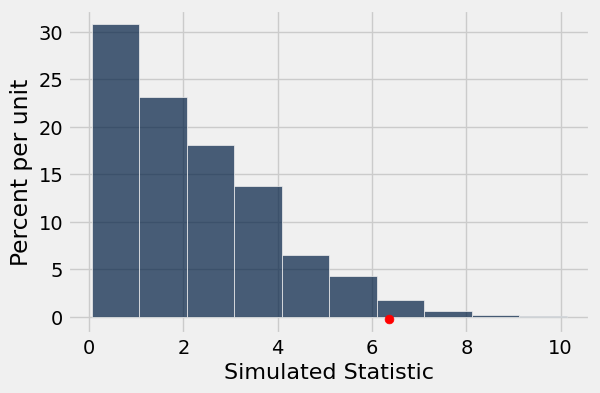

In [25]:
# Run this cell to produce a histogram of the simulated statistics

Table().with_columns('Simulated Statistic', simulated_statistics).hist()
plt.scatter(observed_statistic, -0.002, color='red', s=40);

<!-- END QUESTION -->

---

**Question 1.8.** Using `simulated_statistics`, `observed_statistic`, and `num_simulations`, find the empirical p-value based on the simulation. **(4 points)**

_Hint:_ Reading [11.3.6](https://inferentialthinking.com/chapters/11/3/Decisions_and_Uncertainty.html#the-meaning-of-consistent) might be helpful for this question.


In [26]:
p_value = np.count_nonzero(simulated_statistics >= observed_statistic) / num_simulations
p_value

0.0238

In [27]:
grader.check("q1_8")

q1_8 results: All test cases passed!

---

**Question 1.9.** Assign `correct_doctor` to the number corresponding to the correct statement below. Use the 5% cutoff for the p-value. **(4 points)**

1. The data support Dr. DeNero's position more than they support Dr. Sahai's.
2. The data support Dr. Sahai's position more than they support Dr. DeNero's.

As a reminder, here are the two claims made by Dr. DeNero and Dr. Sahai:
> **Doctor DeNero:** "Oh wow, it's just like tossing a coin that lands heads with chance $\frac{3}{5}$. Heads you get Vaccine 1 and Tails you get Vaccine 2."

>**Doctor Sahai:** "No, it's not. We're not doing anything like tossing a coin."


In [28]:
correct_doctor = 2
correct_doctor

2

In [29]:
grader.check("q1_9")

q1_9 results: All test cases passed!

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 2. Using TVD as a Test Statistic

Before beginning this section, please read [this section](https://inferentialthinking.com/chapters/11/2/Multiple_Categories.html#a-new-statistic-the-distance-between-two-distributions) of the textbook on TVD!

**Total variation distance (TVD)** is a special type of test statistic that we use when we want to compare two distributions of *categorical data*. It is often used when we observe that a set of observed proportions/probabilities is different than what we expect under the null model. 

Consider a six-sided die that we roll 6,000 times. If the die is fair, we would expect that each face comes up $\frac{1}{6}$ of the time. By random chance, a fair die won't always result in equal proportions (that is, we won't get exactly 1,000 of each face). However, if we suspect that the die might be unfair based on the data, we can conduct a hypothesis test using TVD to compare the expected [$\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$, $\frac{1}{6}$] distribution to what is actually observed.

In this part of the homework, we'll look at how we can use TVD to determine the effect that different factors have on happiness. 

We will be working with data from the [Gallup World Poll](https://worldhappiness.report/ed/2023/world-happiness-trust-and-social-connections-in-times-of-crisis/#ranking-of-happiness-2020-2022) that is presented in the World Happiness Report, a survey of the state of global happiness. The survey ranked 137 countries by overall happiness and estimated the influence that economic production, social support, life expectancy, freedom, absence of corruption, and generosity had on population happiness. The study has been repeated for several years, but we'll be looking at data from the 2023 survey.

Run the cell below to load in the `happiness_scores` table.

In [30]:
happiness_scores = Table.read_table("happiness_scores.csv").drop(12, 13, 14).take(np.arange(137))
happiness_scores.show(5)

Country,Happiness Rank,Happiness Score,Standard error of happiness score,Lower Confidence Interval,Upper Confidence Interval,Economy (Log GDP per capita),Family,Health (life expectancy),Freedom,Generosity,Trust (Government Corruption)
Finland,1,7.804,0.036,7.875,7.733,1.888,1.585,0.535,0.772,0.126,0.535
Denmark,2,7.586,0.041,7.667,7.506,1.949,1.548,0.537,0.734,0.208,0.525
Iceland,3,7.53,0.049,7.625,7.434,1.926,1.62,0.559,0.738,0.25,0.187
Israel,4,7.473,0.032,7.535,7.411,1.833,1.521,0.577,0.569,0.124,0.158
Netherlands,5,7.403,0.029,7.46,7.346,1.942,1.488,0.545,0.672,0.251,0.394


Participants in the study were asked to evaluate their life satisfaction from a scale of 0 (worst possible life) to 10 (best possible life). The responses for each country were averaged to create the `Happiness Score`.

The columns `Economy (Log GDP per Capita)`, `Family`, `Health (Life Expectancy)`, `Freedom`, `Generosity`, and `Trust (Government Corruption)` estimate the extent to which each factor influences happiness, both for better or for worse. The happiness score is the sum of these factors; the larger a factor is, the more it contributes to overall happiness. [In other words, if you add up all the factors (in addition to a "Difference from Dystopia" value we excluded in the dataset), you get the happiness score.]

Let's look at the different factors that affect happiness in the United States. Run the cell below to view the row in `us_happiness` that contains data for the United States.

In [31]:
us_happiness = happiness_scores.where("Country", "United States")
us_happiness

Country,Happiness Rank,Happiness Score,Standard error of happiness score,Lower Confidence Interval,Upper Confidence Interval,Economy (Log GDP per capita),Family,Health (life expectancy),Freedom,Generosity,Trust (Government Corruption)
United States,15,6.894,0.047,6.986,6.802,1.98,1.46,0.39,0.557,0.21,0.172


**To compare the different factors, we'll look at the proportion of the happiness score that is attributed to each variable. 
You can find these proportions in the table `us_happiness_factors` after running the cell below.**

*Note:* The factors shown in `us_happiness` don't add up exactly to the happiness score, so we adjusted the proportions to  only account for the data we have access to. The proportions were found by dividing each Happiness Factor value by the sum of all Happiness Factor values in `us_happiness`.

In [32]:
us_happiness_factors = Table().read_table("us_happiness_factors.csv")
us_happiness_factors

Happiness Factor,Proportion of Happiness Score
Economy (GDP per Capita),0.41521
Family,0.306036
Health (Life Expectancy),0.0818086
Freedom,0.116865
Trust (Government Corruption),0.0361179
Generosity,0.0439626


<!-- BEGIN QUESTION -->

---

**Question 2.1.** Suppose we want to test whether or not each factor contributes the same amount to the overall Happiness Score. Define the null hypothesis, alternative hypothesis, and test statistic in the cell below. **(4 points)**

*Note:* Please format your answer as follows:
- Null Hypothesis: ...  
- Alternative Hypothesis: ...  
- Test Statistic: ...  


Null Hypothesis: All factors have the same contribution

Alternative Hypothesis: The contributions of the factors are unequal

Test Statistic: Total Variation Distance (TVD) between the observed and uniform distributions

<!-- END QUESTION -->

---

**Question 2.2.** Write a function `calculate_tvd` that takes in the observed distribution (`obs_dist`) and expected distribution under the null hypothesis (`null_dist`) and calculates the total variation distance. Use this function to set `observed_tvd` to be equal to the observed test statistic. **(4 points)**


In [34]:
null_distribution = make_array(1/6, 1/6, 1/6, 1/6, 1/6, 1/6)

def calculate_tvd(obs_dist, null_dist):
    return np.sum(np.abs(obs_dist - null_dist)) / 2
    
observed_tvd = calculate_tvd(us_happiness_factors.column("Proportion of Happiness Score"), null_distribution)
observed_tvd

0.38791256366666665

In [ ]:
grader.check("q2_2")

q2_2 results: All test cases passed!

---

**Question 2.3.** Create an array called `simulated_tvds` that contains 10,000 simulated values under the null hypothesis. Assume that the original sample consisted of 1,000 individuals. **(4 points)**

*Hint:* The `sample_proportions` function may be helpful to you. Refer to the [Python Reference Sheet](http://data8.org/fa24/reference/) to read up on it!


In [36]:
simulated_tvds = make_array()
for i in range(10000):
    sim_proportions = sample_proportions(1000, null_distribution)
    simulated_tvds = np.append(simulated_tvds, calculate_tvd(sim_proportions, null_distribution))


In [37]:
grader.check("q2_3")

q2_3 results: All test cases passed!

Run the cell below to plot a histogram of your simulated test statistics, as well as a red dot representing the observed value of the test statistic.

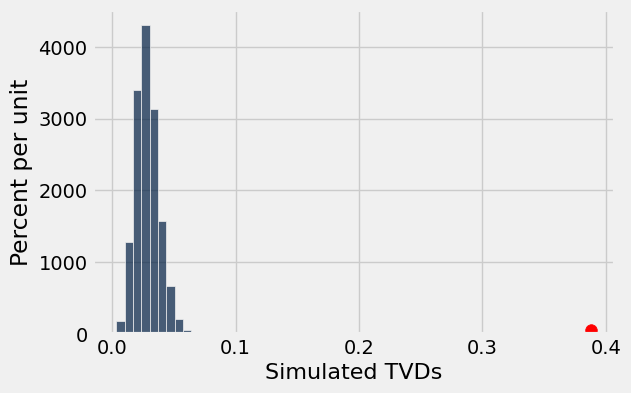

In [38]:
Table().with_column("Simulated TVDs", simulated_tvds).hist()
plt.scatter(observed_tvd, 0.5, color='red', s=70, zorder=2);
plt.show();

---

**Question 2.4.** Use your simulated statistics to calculate the p-value of your test. Make sure that this number is consistent with what you observed in the histogram above. **(4 points)**


In [39]:
p_value_tvd = np.count_nonzero(simulated_tvds >= observed_tvd) / num_simulations
p_value_tvd

0.0

In [40]:
grader.check("q2_4")

q2_4 results: All test cases passed!

<!-- BEGIN QUESTION -->

---

**Question 2.5.** What can you conclude about how each factor contributes to the overall happiness score in the US? Explain your answer using the results of your hypothesis test. Assume a p-value cutoff of 5%. **(4 points)**


_Type your answer here, replacing this text._

<!-- END QUESTION -->

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## 3. Who is Older?

Data scientists have drawn a simple random sample of size 500 from a large population of adults. Each member of the population happened to identify as either "male" or "female". (Though many people identify outside of the gender binary, in this particular population of interest, each member happened to identify as either male or female.) Data was collected on several attributes of the sampled people, including age. The table `sampled_ages` contains one row for each person in the sample, with columns containing the individual's gender identity.

In [41]:
sampled_ages = Table.read_table('age.csv') 
sampled_ages.show(5)

Gender,Age
male,23
male,29
male,29
female,49
female,33


---

**Question 3.1.** How many females were there in our sample? Please use the provided skeleton code. **(4 points)**

*Hint:* Keep in mind that `.group` sorts categories in alphabetical order!


In [50]:
num_females = sampled_ages.group("Gender").column("count").item(0)
num_females

260

In [44]:
grader.check("q3_1")

q3_1 results: All test cases passed!

---

**Question 3.2.** Complete the cell below so that `avg_male_vs_female` evaluates to `True` if the sampled males are older than the sampled females on average, and `False` otherwise. Use Python code to achieve this. **(4 points)**


In [52]:
group_mean_tbl = sampled_ages.group("Gender", np.mean)
group_mean_tbl.show()

Gender,Age mean
female,42.0692
male,43.3833


In [54]:
group_mean_tbl = sampled_ages.group("Gender", np.mean)
group_means = group_mean_tbl.column("Age mean")
avg_male_vs_female = group_means.item(1) > group_means.item(0)
avg_male_vs_female

True

In [55]:
grader.check("q3_2")

q3_2 results: All test cases passed!

---

**Question 3.3.** The data scientists want to use the data to test whether males are older than females. One of the following statements is their null hypothesis and another is their alternative hypothesis. Assign `null_statement_number` and `alternative_statement_number` to the numbers of the correct statements in the code cell below. **(4 points)**

1. In the sample, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
2. In the population, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
3. The age distributions of males and females in the population are different due to chance.
4. The males in the sample are older than the females, on average.
5. The males in the population are older than the females, on average.
6. The average ages of the males and females in the population are different.


In [56]:
null_statement_number = 2
alternative_statement_number = 5

In [57]:
grader.check("q3_3")

q3_3 results: All test cases passed!

---

**Question 3.4.** The data scientists have decided to use a permutation test. Assign `permutation_test_reason` to the number corresponding to the reason they made this choice. **(4 points)**

1. Since a person's age shouldn't be related to their gender, it doesn't matter who is labeled "male" and who is labeled "female", so you can use permutations.
2. Under the null hypothesis, permuting the labels in the `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.
3. Under the null hypothesis, permuting the rows of `sampled_ages` table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.

*Note:* Check out [12.1](https://inferentialthinking.com/chapters/12/1/AB_Testing.html#permutation-test) for a refresher on random permutations and permutation tests.


In [58]:
permutation_test_reason = 2
permutation_test_reason

2

In [59]:
grader.check("q3_4")

q3_4 results: All test cases passed!

---

**Question 3.5.** To test their hypotheses, the data scientists have followed our textbook's advice and chosen a test statistic where the following statement is true: Large values of the test statistic favor the alternative hypothesis.

The data scientists' test statistic is one of the two options below. Which one is it? Assign the appropriate number to the variable `correct_test_stat`. **(4 points)**

1. "male age average - female age average" in a sample created by randomly shuffling the male/female labels
2. "|male age average - female age average|" in a sample created by randomly shuffling the male/female labels


In [62]:
correct_test_stat = 1
correct_test_stat

1

In [63]:
grader.check("q3_5")

q3_5 results: All test cases passed!

---

**Question 3.6.** Complete the cell below so that `observed_statistic_ab` evaluates to the observed value of the data scientists' test statistic. Use as many lines of code as you need, and remember that you can use any quantity, table, or array that you created earlier. **(4 points)**


In [64]:
observed_statistic_ab = group_means.item(1) - group_means.item(0)
observed_statistic_ab

1.314102564102562

In [65]:
grader.check("q3_6")

q3_6 results: All test cases passed!

---

**Question 3.7.** Assign `shuffled_labels` to an array of shuffled male/female labels. The rest of the code puts the array in a table along with the data in `sampled_ages`. **(4 points)**


In [75]:
shuffled_labels = sampled_ages.column('Gender').copy()
np.random.shuffle(shuffled_labels)
original_with_shuffled_labels = sampled_ages.with_columns('Shuffled Label', shuffled_labels)
original_with_shuffled_labels

Gender,Age,Shuffled Label
male,23,female
male,29,male
female,29,female
female,49,male
female,33,female
female,31,female
male,60,female
female,38,male
female,60,male
female,27,female


In [76]:
grader.check("q3_7")

q3_7 results: All test cases passed!

---

**Question 3.8.** The comparison below uses the array `shuffled_labels` from Question 3.7 and the count `num_females` from Question 3.1.

For this comparison, assign the correct letter as a string (e.g. `correct_q8 = 'A'`) from one of the following options to the variable `correct_q8`. **Pretend this is a midterm problem and do not solve it using a code cell.** **(4 points)**

`comp = np.count_nonzero(shuffled_labels == 'female') == num_females`

A. `comp` is set to `True`.<br>
B. `comp` is set to `False`.<br>
C. `comp` is set to `True` or `False`, depending on how the shuffle came out.


In [77]:
correct_q8 = 'A'
correct_q8

'A'

In [78]:
grader.check("q3_8")

q3_8 results: All test cases passed!

---

**Question 3.9.** Define a function `simulate_one_statistic` that takes no arguments and returns one simulated value of the test statistic. We've given you a skeleton, but feel free to approach this question in a way that makes sense to you. Use as many lines of code as you need. Refer to the code you have previously written in this problem, as you might be able to re-use some of it. **(4 points)**


In [79]:
def simulate_one_statistic():
    "Returns one value of our simulated test statistic"
    shuffled_labels =  sampled_ages.column('Gender').copy()
    np.random.shuffle(shuffled_labels)
    shuffled_tbl = sampled_ages.with_column('Shuffled Gender', shuffled_labels)
    group_means = shuffled_tbl.group("Gender",np.mean)
    return group_means.column("Age mean").item(1) - group_means.column("Age mean").item(0)

In [80]:
grader.check("q3_9")

q3_9 results: All test cases passed!

After you have defined your function, run the following cell a few times to see how the statistic varies.

In [81]:
simulate_one_statistic()

-0.9134615384615401

---

**Question 3.10.** Complete the cell to simulate 5,000 values of the statistic. We have included the code that draws the empirical distribution of the statistic and shows the value of `observed_statistic_ab` from Question 3.6. Feel free to use as many lines of code as you need. **(4 points)**

*Note:* This cell will take around a minute to run.


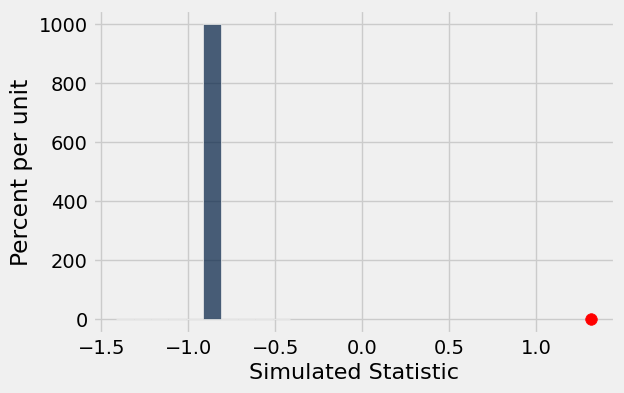

In [82]:
simulated_statistics_ab = make_array()

for _ in range(5000):
    simulated_statistics_ab = np.append(simulated_statistics_ab, simulate_one_statistic())

# Do not change these lines
Table().with_columns('Simulated Statistic', simulated_statistics_ab).hist()
plt.scatter(observed_statistic_ab, -0.002, color='red', s=70);

---

**Question 3.11.** Use the simulation to find an empirical approximation to the p-value. Assign `p_val` to the appropriate p-value from this simulation. Then, assign `conclusion` to either `null_hyp` or `alt_hyp`. **(4 points)** 

*Note:* Assume that we use the 5% cutoff for the p-value.


In [83]:
# These are variables provided for you to use.
null_hyp = 'The data are consistent with the null hypothesis.'
alt_hyp = 'The data support the alternative more than the null.'

p_val = np.count_nonzero(simulated_statistics_ab >= observed_statistic_ab) / 5000
conclusion = null_hyp if p_val > 0.05 else alt_hyp

p_val, conclusion # Do not change this line

(0.0, 'The data support the alternative more than the null.')

In [84]:
grader.check("q3_11")

q3_11 results: All test cases passed!

You're done with Homework 6!  

**Important submission steps:** 
1. Run the tests and verify that they all pass.
2. Choose **Save Notebook** from the **File** menu, then **run the final cell**. 
3. Click the link to download the zip file.
4. Go to [Gradescope](https://www.gradescope.com) and submit the zip file to the corresponding assignment. The name of this assignment is "HW 06 Autograder". 

**It is your responsibility to make sure your work is saved before running the last cell.**

## Pets of Data 8
**Gus** is enjoying the weather we're having lately. Congrats on surviving the heat and finishing homework 7!

<img src="./gus2.jpeg" width="40%" alt="Black and white cat sitting next to window"/>

## Written Work Submission

Below, you will see two cells. Running the first cell will automatically generate a PDF of all questions that need to be manually graded, and running the second cell will automatically generate a zip with your autograded answers. You are responsible for submitting both the coding portion (the zip) and the written portion (the PDF) to their respective Gradescope portals. **Please save before exporting!**

> **Important: You must correctly assign the pages of your PDF after you submit to the correct gradescope assignment. If your pages are not correctly assigned and/or not in the correct PDF format by the deadline, we reserve the right to award no points for your written work.**

If there are issues with automatically generating the PDF in the first cell, you can try downloading the notebook as a PDF by clicking on `File -> Save and Export Notebook As... -> Webpdf`. If that doesn't work either, you can manually take screenshots of your answers to the manually graded questions and submit one single PDF of your screenshots. Either way, **you are responsible for ensuring your submision follows our requirements, we will NOT be granting regrade requests for submissions that don't follow instructions.**

**You must submit the PDF generated via one of these methods, we will not accept screenshots or Word documents.**

In [85]:
from otter.export import export_notebook
from os import path
from IPython.display import display, HTML
name = 'hw07'
export_notebook(f"{name}.ipynb", filtering=True, pagebreaks=True)
if(path.exists(f'{name}.pdf')):
    display(HTML(f"Download your PDF <a href='{name}.pdf' download>here</a>."))
else:
    print("\n Pdf generation failed, please try the other methods described above")

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [86]:
# Save your notebook first, then run this cell to export your submission.
grader.export(pdf=False, run_tests=True)

Running your submission against local test cases...


Your submission received the following results when run against available test cases:

    q1_1 results: All test cases passed!

    q1_4 results: All test cases passed!

    q1_5 results: All test cases passed!

    q1_6 results: All test cases passed!

    q1_8 results: All test cases passed!

    q1_9 results: All test cases passed!

    q2_2 results: All test cases passed!

    q2_3 results: All test cases passed!

    q2_4 results: All test cases passed!

    q3_1 results: All test cases passed!

    q3_2 results: All test cases passed!

    q3_3 results: All test cases passed!

    q3_4 results: All test cases passed!

    q3_5 results: All test cases passed!

    q3_6 results: All test cases passed!

    q3_7 results: All test cases passed!

    q3_8 results: All test cases passed!

    q3_9 results: All test cases passed!

    q3_11 results: All test cases passed!


/home/hdd/anaconda3/envs/KHDL/lib/python3.12/site-packages/otter/check/utils.py:115: RuntimeWarning: [IPKernelApp] WARNING | bibtex had problems, most likely because there were no citations

  warnings.warn(results.stderr.decode("utf-8"), RuntimeWarning)
